In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
#import pyccl as ccl
import math
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from functools import partial
from scipy.integrate import quad, dblquad

import pyccl as ccl
import camb
from camb import model, initialpower
import cosmology

# cosmology

In [2]:
h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

# power spec, transfer, Db

In [3]:
K=K=np.logspace(-3,1,50)
z1=1
b=3
p=1
fNL=10
mod='bbks'
P=[b**2*cosmology.Pm(k,z1, cosmo) for k in K]
Pfnl=[(b+cosmology.deltab_test(k,fNL,b,p,mod,z1, cosmo))**2*cosmology.Pm(k,z1,cosmo) for k in K]

Text(0, 0.5, '$P_{\\rm gg}(k)$')

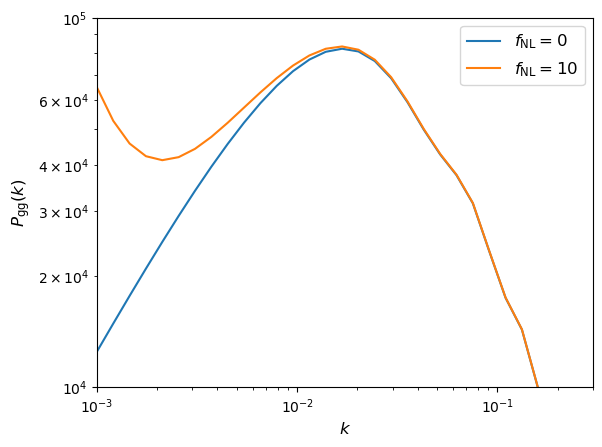

In [4]:
plt.figure(dpi=100)
plt.plot(K,P,label=r'$f_{\rm NL}=0$')
plt.plot(K,Pfnl,label=r'$f_{\rm NL}=10$')
plt.legend(fontsize=12)
plt.loglog()
plt.xlim(0.001,0.3)
plt.ylim(10**4,10**5)
plt.xlabel('$k$',fontsize=12)
plt.ylabel(r'$P_{\rm gg}(k)$',fontsize=12)